# Machine Learning Pipeline for Credit Risk Assessment

**Author:** Viswa Musunuri

---

## Project Objective

This project develops an end-to-end machine learning pipeline to predict credit risk using the German Credit dataset. The goal is to compare multiple classification models and recommend a production-ready solution based on statistical performance and business risk considerations.

Credit risk prediction is a binary classification problem where the model must distinguish between low-risk (good) and high-risk (bad) applicants. False negatives (approving a risky applicant) can cause financial loss, making recall for high-risk cases particularly important in business decision-making.

Reproducibility Setup

In [ ]:
import numpy as np
import random
import os

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Reproducibility seed set to:", SEED)

Reproducibility seed set to: 42


Import Required Libraries

In [ ]:
# Data Handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


Load Dataset from Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After mounting, your Google Drive files will be accessible under the `/content/drive` directory. For example, if you have a file named `my_data.csv` in the root of your Drive, you can load it using pandas like this:

In [ ]:
!ls -F '/content/drive/MyDrive/T2_Project_Srinivas Musunuri/'

Data/  Models/	Notebooks/  Report/  Visualizations/


In [ ]:
!ls -F '/content/drive/MyDrive/T2_Project_Srinivas Musunuri/Data/'

'german_credit_data - german_credit_data.csv'


In [ ]:
!ls -F '/content/drive/MyDrive/T2_Project_Srinivas Musunuri/Notebooks/'

01_EDA_Preprocessing.ipynb  03_Model_Evaluation.ipynb
02_Model_Development.ipynb


In [ ]:
data_path = "/content/drive/MyDrive/T2_Project_Srinivas Musunuri/Data/german_credit_data - german_credit_data.csv"
viz_path = "/content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/"

df = pd.read_csv(data_path)

print("Dataset Loaded Successfully.")
df.head()

Dataset Loaded Successfully.


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,56,male,1,own,little,moderate,6745,22,car,good
1,69,female,2,free,moderate,moderate,10437,70,car,good
2,46,male,3,own,quite rich,little,9763,8,car,good
3,32,female,1,own,moderate,little,18964,70,radio/TV,bad
4,60,male,2,own,moderate,little,17650,14,domestic appliances,good


Initial Data Inspection

In [ ]:
print("Shape of dataset:", df.shape)
print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape of dataset: (1000, 10)

Data Types:

Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

Missing Values:

Age                  0
Sex                  0
Job                  0
Housing              0
Saving accounts     85
Checking account    95
Credit amount        0
Duration             0
Purpose              0
Risk                 0
dtype: int64

Duplicate Rows: 0


Basic Statistical Summary

In [ ]:
df.describe(include='all')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000,1000.000000,1000,915,905,1000.000000,1000.000000,1000,1000
unique,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,523,NaN,589,412,505,NaN,NaN,289,604
mean,46.247000,NaN,1.306000,NaN,NaN,NaN,9943.912000,36.810000,NaN,NaN
std,16.288072,NaN,0.901763,NaN,NaN,NaN,5626.476201,19.334418,NaN,NaN
min,18.000000,NaN,0.000000,NaN,NaN,NaN,298.000000,4.000000,NaN,NaN
25%,33.000000,NaN,1.000000,NaN,NaN,NaN,5021.250000,21.000000,NaN,NaN
50%,46.000000,NaN,1.000000,NaN,NaN,NaN,9814.000000,36.000000,NaN,NaN
75%,60.250000,NaN,2.000000,NaN,NaN,NaN,14785.500000,53.000000,NaN,NaN


Target Distribution Analysis

Risk
good    604
bad     396
Name: count, dtype: int64


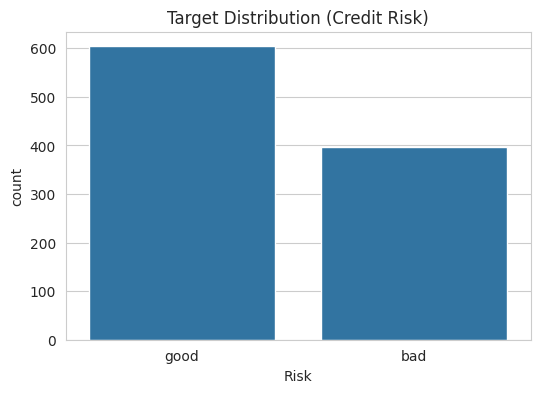

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/Target Distribution (Credit Risk).png


In [ ]:
print(df["Risk"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Risk", data=df)
plt.title("Target Distribution (Credit Risk)")
plt.savefig(f"{viz_path}Target Distribution (Credit Risk).png")
plt.show()
print(f"Plot saved: {viz_path}Target Distribution (Credit Risk).png")

The dataset shows a class imbalance between good and bad credit applicants.
This imbalance is important because standard accuracy may be misleading.
In credit risk modeling, false negatives (predicting a risky applicant as safe) are more costly than false positives.

Numerical Feature Analysis

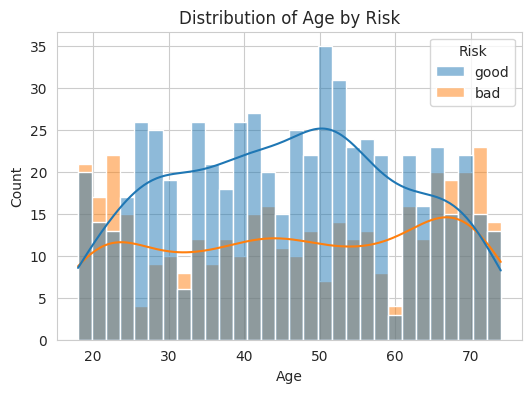

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/Age_distribution_by_risk.png


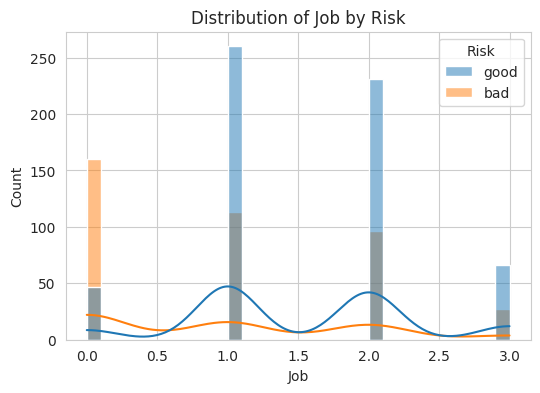

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/Job_distribution_by_risk.png


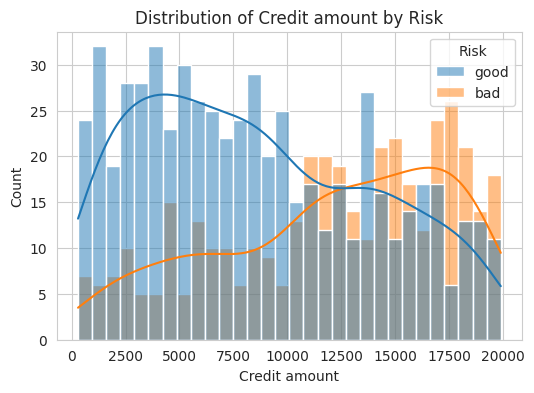

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/Credit amount_distribution_by_risk.png


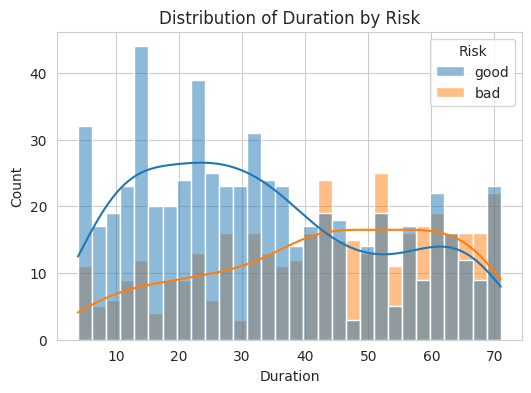

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/Duration_distribution_by_risk.png


In [ ]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# The 'Risk' column is not numeric and is therefore not included by select_dtypes.
# So, this line is not needed.
# numeric_features.remove("Risk")

for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="Risk", kde=True, bins=30)
    plt.title(f"Distribution of {col} by Risk")
    plt.savefig(f"{viz_path}{col}_distribution_by_risk.png")
    plt.show()
    print(f"Plot saved: {viz_path}{col}_distribution_by_risk.png")

Correlation Heatmap

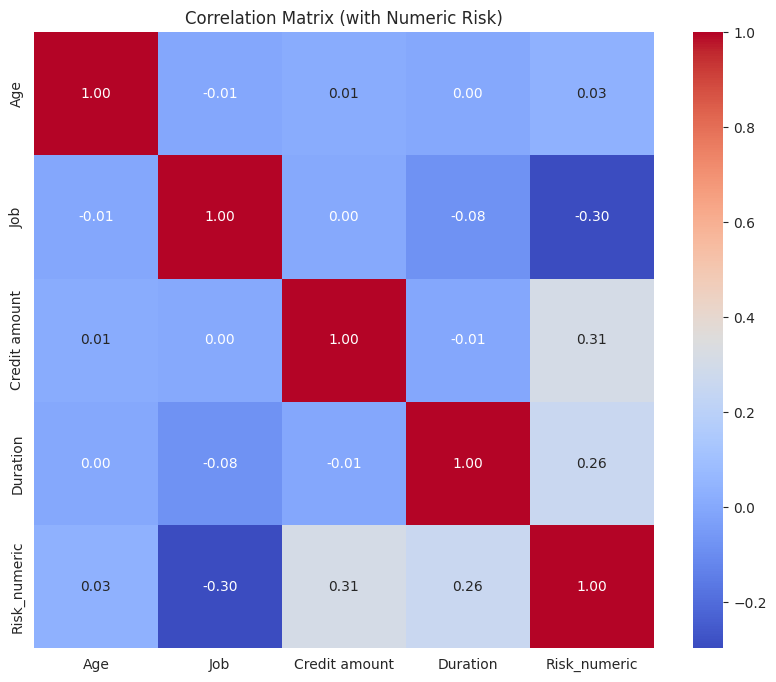

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/correlation_matrix_numeric_risk.png


In [ ]:
plt.figure(figsize=(10,8))
# Map 'good' to 0 and 'bad' to 1 for numerical correlation calculation
df_corr = df.copy()
df_corr['Risk_numeric'] = df_corr['Risk'].map({'good': 0, 'bad': 1})

# Include the new numeric 'Risk' column for correlation
corr_matrix = df_corr[numeric_features + ['Risk_numeric']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (with Numeric Risk)")
plt.savefig(f"{viz_path}correlation_matrix_numeric_risk.png")
plt.show()
print(f"Plot saved: {viz_path}correlation_matrix_numeric_risk.png")

The correlation matrix helps identify relationships between numerical variables.
Highly correlated features may introduce multicollinearity, which affects linear models like Logistic Regression but is less problematic for tree-based models.

Categorical Feature Analysis

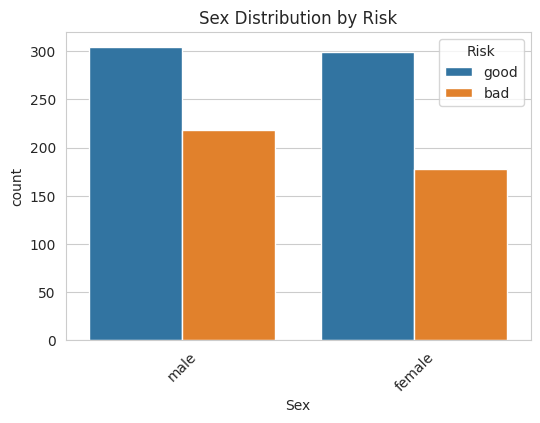

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/Sex_distribution_by_risk.png


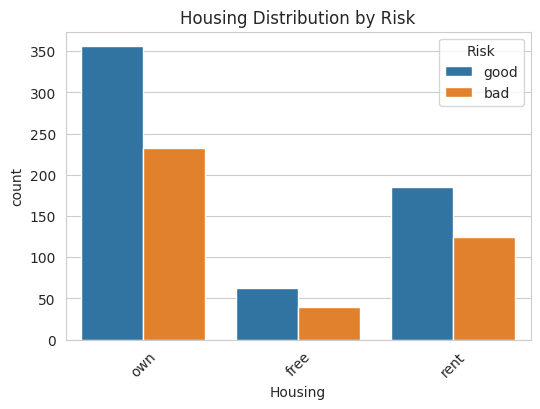

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/Housing_distribution_by_risk.png


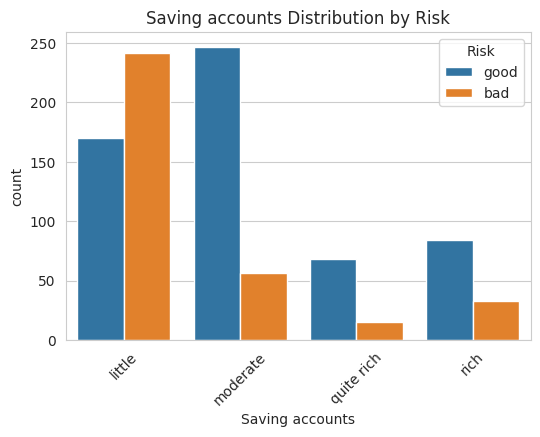

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/Saving accounts_distribution_by_risk.png


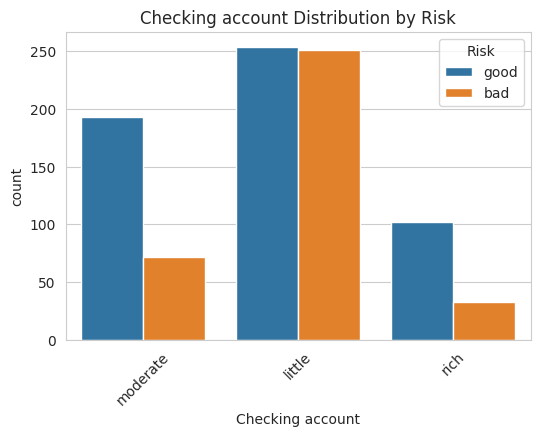

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/Checking account_distribution_by_risk.png


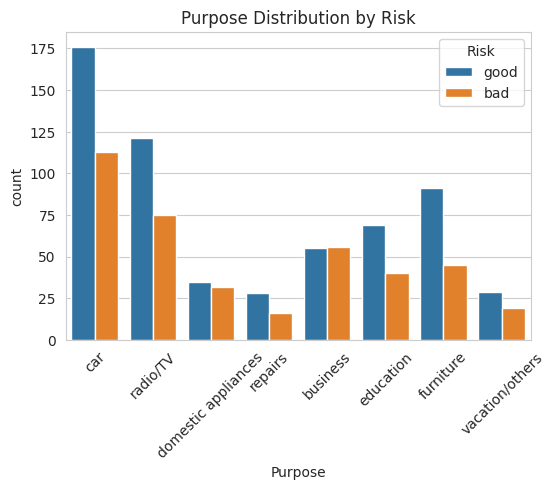

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/Purpose_distribution_by_risk.png


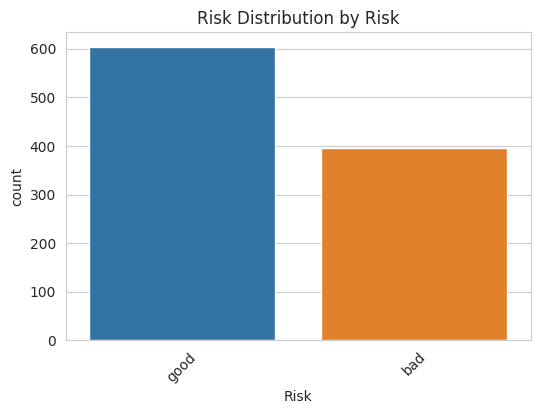

Plot saved: /content/drive/MyDrive/T2_Project_Srinivas Musunuri/Visualizations/Risk_distribution_by_risk.png


In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Risk", data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} Distribution by Risk")
    plt.savefig(f"{viz_path}{col}_distribution_by_risk.png")
    plt.show()
    print(f"Plot saved: {viz_path}{col}_distribution_by_risk.png")

Feature Engineering

In [ ]:
# Example Feature Engineering
if "Credit amount" in df.columns and "Duration" in df.columns:
    df["credit_amount_per_month"] = df["Credit amount"] / df["Duration"]
    print("Feature credit_amount_per_month created successfully.")

Feature credit_amount_per_month created successfully.


Encode Target Variable

In [ ]:
df["Risk"] = df["Risk"].map({"good": 0, "bad": 1})

print(df["Risk"].value_counts())

Risk
0    604
1    396
Name: count, dtype: int64


Define Features & Target

In [ ]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 10)
Target shape: (1000,)


Stratified Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 10)
Test shape: (200, 10)


Define Preprocessing Pipelines

In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline defined successfully.")

Preprocessing pipeline defined successfully.


Save Processed Splits to Drive

In [ ]:
save_path = "/content/drive/MyDrive/T2_Project_Srinivas Musunuri/Data/"

X_train.to_csv(save_path + "X_train.csv", index=False)
X_test.to_csv(save_path + "X_test.csv", index=False)
y_train.to_csv(save_path + "y_train.csv", index=False)
y_test.to_csv(save_path + "y_test.csv", index=False)

print("Train/Test splits saved successfully.")

Train/Test splits saved successfully.
